In [149]:
import torch
import numpy as np
import json
import os
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from base import BaseDataLoader, DatasetSubset
from collections import OrderedDict
import json
from typing import Dict, Any, Tuple
import ijson
import pickle

import torch
import numpy as np
import json
import os
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from collections import OrderedDict
from typing import Dict, Any, Tuple

class StreamingFEMNISTManager:
    def __init__(self, json_dir: str, cache_size: int = 1000):
        self.json_dir = json_dir
        self.index = {}  
        self.cache = OrderedDict()
        self.cache_size = cache_size
        
        # Check for existing index file
        index_path = os.path.join(json_dir, 'user_index.json')
        if os.path.exists(index_path):
            print("Loading existing index file...")
            with open(index_path, 'r') as f:
                self.index = json.load(f)
        else:
            print("Creating new index file...")
            self._create_index()
            # Save the index
            with open(index_path, 'w') as f:
                json.dump(self.index, f)

    def _create_index(self):
        """Create index of user positions with improved accuracy"""
        for file_name in os.listdir(self.json_dir):
            if not file_name.endswith('.json'):
                continue
                
            file_path = os.path.join(self.json_dir, file_name)
            print(f"Indexing file: {file_path}")
            
            # First pass: get users and num_samples
            with open(file_path, 'r') as f:
                data = json.load(f)
                users = data['users']
                num_samples = data['num_samples']
            
            # Second pass: find exact positions
            with open(file_path, 'r') as f:
                data_str = f.read()
            
            user_data_start = data_str.find('"user_data"')
            
            for i, user in enumerate(users):
                user_marker = f'"{user}":'
                user_start = data_str.find(user_marker, user_data_start)
                
                if user_start == -1:
                    print(f"Warning: Could not find start position for user {user}")
                    continue
                
                # Find end position (either next user or end of section)
                end_pos = len(data_str)
                if i < len(users) - 1:
                    next_user = users[i + 1]
                    next_marker = f'"{next_user}":'
                    next_pos = data_str.find(next_marker, user_start + len(user_marker))
                    if next_pos != -1:
                        end_pos = next_pos
                
                self.index[user] = {
                    'start': user_start,
                    'end': end_pos,
                    'num_samples': num_samples[i],
                    'file': file_path
                }

    def _parse_user_data(self, file_handle, user_pos: Dict[str, Any]) -> Dict[str, Any]:
        """
        Parse user data using precise position information
        """
        file_handle.seek(user_pos['start'])
        data_chunk = file_handle.read(user_pos['end'] - user_pos['start'])
        # Prepare the JSON string by adding enclosing brackets
        json_str = "{" + data_chunk.strip().rstrip(',') + "}"
        
        try:
            user_data = json.loads(json_str)
            # Extract only the user's data we need
            user_id = list(user_data.keys())[0]  # There should be only one user
            return {
                'x': user_data[user_id]['x'],
                'y': user_data[user_id]['y']
            }
        except json.JSONDecodeError as e:
            print(f"Error parsing user data: {e}")
            return {'x': [], 'y': []}

    def _trim_cache(self):
        """Trim cache using LRU strategy"""
        target_size = int(0.9 * self.cache_size)
        while len(self.cache) > target_size:
            self.cache.popitem(last=False)
            
    def _update_cache(self, user_id: str, data: Dict[str, Any]):
        """Update cache with new user data"""
        if user_id in self.cache:
            self.cache.pop(user_id)
        self.cache[user_id] = data
        if len(self.cache) > self.cache_size:
            self._trim_cache()

    def load_users_data(self, selected_users):
        """Load user data with improved efficiency"""
        user_data = {}
        file_groups = {}
        
        # First check cache
        for user in selected_users:
            if user in self.cache:
                data = self.cache.pop(user)
                self.cache[user] = data
                user_data[user] = data
                continue
            
            # Group uncached users by file
            file_path = self.index[user]['file']
            if file_path not in file_groups:
                file_groups[file_path] = []
            file_groups[file_path].append(user)
        
        # Load uncached users by file
        for file_path, users in file_groups.items():
            with open(file_path, 'r') as f:
                for user in users:
                    user_pos = self.index[user]
                    data = self._parse_user_data(f, user_pos)
                    user_data[user] = data
                    self._update_cache(user, data)
        
        return user_data

# The FEMNISTDataset class remains unchanged
class FEMNISTDataset(Dataset):
    def __init__(self, data, transform=None):
        self.data = []
        self.targets = []
        for x, y in zip(data['x'], data['y']):
            self.data.append(torch.tensor(x).reshape(28, 28).unsqueeze(0))
            self.targets.append(y)
        self.transform = transform

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        img = self.data[idx]
        target = self.targets[idx]
        
        if self.transform:
            # img = self.transform(img)
            img = img
            
        return img, target



class FEMNISTDataLoader(BaseDataLoader):
    def __init__(self, data_dir: str, n_clients: int, batch_size: int):
        super().__init__(data_dir, n_clients, batch_size)
        self.transform = transforms.Compose([
            transforms.Normalize((0.1307,), (0.3081,))
        ])
        self.json_dir = os.path.join(data_dir, "all_data")
        self.streaming_manager = StreamingFEMNISTManager(self.json_dir)

    def load_data(self):
        """Load and prepare the dataset with non-IID distribution"""
        # Select random clients for this round
        all_users = list(self.streaming_manager.index.keys())
        selected_users = np.random.choice(all_users, self.n_clients, replace=False)
        
        # Load selected users' data
        user_data = self.streaming_manager.load_users_data(selected_users)
        
        # Create datasets and prepare for weight calculation
        train_loaders = []
        train_sizes = []  # Store training sizes for weight calculation
        
        # Keep track of validation and test data
        val_data = {'x': [], 'y': []}
        test_data = {'x': [], 'y': []}
        
        for user in selected_users:
            data = user_data[user]
            n_samples = len(data['y'])
            
            # Create copies for training data after removing val/test samples
            train_data = {'x': data['x'].copy(), 'y': data['y'].copy()}
            
            # Take samples for validation and test if needed
            if len(val_data['x']) < 1000:  # Arbitrary threshold for val set
                val_size = min(int(0.1 * n_samples), 100)  # Take max 100 samples per client
                val_indices = np.random.choice(n_samples, val_size, replace=False)
                for idx in sorted(val_indices, reverse=True):  # Remove from end to keep indices valid
                    val_data['x'].append(train_data['x'].pop(idx))
                    val_data['y'].append(train_data['y'].pop(idx))
                    
            if len(test_data['x']) < 1000:  # Arbitrary threshold for test set
                test_size = min(int(0.1 * n_samples), 100)  # Take max 100 samples per client
                test_indices = np.random.choice(len(train_data['y']), test_size, replace=False)
                for idx in sorted(test_indices, reverse=True):
                    test_data['x'].append(train_data['x'].pop(idx))
                    test_data['y'].append(train_data['y'].pop(idx))
            
            # Create dataset with remaining training data
            train_dataset = FEMNISTDataset(train_data, self.transform)
            train_loader = DataLoader(
                train_dataset,
                batch_size=self.batch_size,
                shuffle=True
            )
            train_loaders.append(train_loader)
            
            # Store size of training data for weight calculation
            train_sizes.append(len(train_data['y']))
        
        # Calculate weights based on training data sizes
        total_train_samples = sum(train_sizes)
        client_weights = [size / total_train_samples for size in train_sizes]
        
        # Create validation and test datasets
        val_dataset = FEMNISTDataset(val_data, self.transform)
        test_dataset = FEMNISTDataset(test_data, self.transform)
        
        val_loader = DataLoader(val_dataset, batch_size=self.batch_size, shuffle=False)
        test_loader = DataLoader(test_dataset, batch_size=self.batch_size, shuffle=False)
        
        return train_loaders, val_loader, test_loader, client_weights, 1

    @property
    def client_weights(self):
        """Get the weights of currently selected clients"""
        if hasattr(self, '_client_weights'):
            return self._client_weights
        return None
    



In [124]:
import os

data_dir = "../data/FEMNIST"
json_dir = os.path.join(data_dir, "all_data")

# Check files
json_files = [f for f in os.listdir(json_dir) if f.endswith('.json')]
print(f"Found {len(json_files)} JSON files: {json_files}")

Found 35 JSON files: ['all_data_0.json', 'all_data_14.json', 'all_data_25.json', 'all_data_4.json', 'all_data_21.json', 'all_data_10.json', 'all_data_8.json', 'all_data_29.json', 'all_data_18.json', 'all_data_31.json', 'all_data_9.json', 'all_data_34.json', 'all_data_28.json', 'all_data_19.json', 'all_data_30.json', 'all_data_1.json', 'all_data_15.json', 'all_data_24.json', 'all_data_5.json', 'all_data_20.json', 'all_data_11.json', 'all_data_32.json', 'all_data_3.json', 'all_data_17.json', 'all_data_26.json', 'all_data_7.json', 'all_data_22.json', 'all_data_13.json', 'all_data_2.json', 'all_data_16.json', 'all_data_27.json', 'all_data_6.json', 'all_data_23.json', 'all_data_12.json', 'all_data_33.json']


In [138]:
import json
with open(os.path.join(json_dir, json_files[0]), 'r') as f:
    data = json.load(f)
    
print("Keys in JSON file:", data.keys())
print(f"Number of users: {len(data['users'])}")
print(f"Sample distribution: {data['num_samples'][:5]}")  # First 5 users

Keys in JSON file: dict_keys(['users', 'num_samples', 'user_data'])
Number of users: 100
Sample distribution: [180, 172, 173, 179, 179]


In [141]:
manager = StreamingFEMNISTManager(json_dir)
print(f"Number of indexed users: {len(manager.index)}")
print("\nFirst 3 user positions:")
for user in list(manager.index.keys())[:3]:
    print(f"User {user}: {manager.index[user]}")

Loading existing index file...
Number of indexed users: 3500

First 3 user positions:
User f3627_46: {'start': 1742, 'end': 1018075, 'num_samples': 180, 'file': '../data/FEMNIST/all_data/all_data_0.json'}
User f3724_32: {'start': 1018075, 'end': 1947221, 'num_samples': 172, 'file': '../data/FEMNIST/all_data/all_data_0.json'}
User f3875_35: {'start': 1947221, 'end': 2867995, 'num_samples': 173, 'file': '../data/FEMNIST/all_data/all_data_0.json'}


In [150]:
import random
test_users = random.sample(list(manager.index.keys()), 3)
user_data = manager.load_users_data(test_users)

for user in test_users:
    print(f"\nUser {user}:")
    print(f"Number of samples: {len(user_data[user]['x'])}")
    print(f"Expected samples: {manager.index[user]['num_samples']}")
    print(f"X shape: {len(user_data[user]['x'][0])}")  # Should be 784 for MNIST
    print(f"Y values range: {min(user_data[user]['y'])} to {max(user_data[user]['y'])}")


User f0270_23:
Number of samples: 250
Expected samples: 250
X shape: 784
Y values range: 0 to 60

User f0055_09:
Number of samples: 374
Expected samples: 374
X shape: 784
Y values range: 0 to 61

User f0437_05:
Number of samples: 360
Expected samples: 360
X shape: 784
Y values range: 0 to 61


In [151]:
from torch.utils.data import DataLoader

# Create dataset for one user
test_user = test_users[0]
dataset = FEMNISTDataset(user_data[test_user])

print(f"\nDataset statistics:")
print(f"Dataset size: {len(dataset)}")
print(f"First image shape: {dataset[0][0].shape}")  # Should be [1, 28, 28]
print(f"Label distribution: {torch.tensor([dataset[i][1] for i in range(len(dataset))]).unique(return_counts=True)}")


Dataset statistics:
Dataset size: 250
First image shape: torch.Size([1, 28, 28])
Label distribution: (tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 15, 16, 17, 18,
        19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36,
        37, 39, 40, 43, 44, 46, 47, 48, 49, 50, 52, 53, 55, 56, 58, 59, 60]), tensor([ 9, 13, 11, 12, 12,  6, 10, 12,  3,  3,  1,  2,  4,  1,  4,  1,  1, 13,
         2,  1,  2,  6,  4, 12,  6,  1,  1,  7,  2,  6,  2,  2,  1,  1,  1,  3,
         1,  4, 19,  8,  1,  1,  8,  2,  6,  1,  1,  7,  9,  1,  1,  1,  1]))


In [152]:
loader = FEMNISTDataLoader(data_dir, n_clients=5, batch_size=32)
train_loaders, val_loader, test_loader, client_weights, _ = loader.load_data()

print("\nDataLoader statistics:")
print(f"Number of clients: {len(train_loaders)}")
print(f"Client weights sum: {sum(client_weights):.2f}")  # Should be 1.0
print("\nPer-client statistics:")
for i, train_loader in enumerate(train_loaders):
    total_samples = len(train_loader.dataset)
    labels = torch.tensor([train_loader.dataset[i][1] for i in range(total_samples)])
    unique_labels = labels.unique()
    print(f"\nClient {i}:")
    print(f"Training samples: {total_samples}")
    print(f"Unique labels: {len(unique_labels)}")
    print(f"Weight: {client_weights[i]:.3f}")

print("\nValidation/Test sets:")
print(f"Validation set size: {len(val_loader.dataset)}")
print(f"Test set size: {len(test_loader.dataset)}")

Loading existing index file...

DataLoader statistics:
Number of clients: 5
Client weights sum: 1.00

Per-client statistics:

Client 0:
Training samples: 133
Unique labels: 48
Weight: 0.207

Client 1:
Training samples: 128
Unique labels: 41
Weight: 0.199

Client 2:
Training samples: 136
Unique labels: 45
Weight: 0.211

Client 3:
Training samples: 145
Unique labels: 50
Weight: 0.225

Client 4:
Training samples: 102
Unique labels: 46
Weight: 0.158

Validation/Test sets:
Validation set size: 78
Test set size: 78


In [153]:
import psutil
process = psutil.Process()

def print_memory_usage():
    print(f"Memory usage: {process.memory_info().rss / 1024 / 1024:.2f} MB")

print("\nInitial memory:")
print_memory_usage()

# Load some data
_ = loader.load_data()
print("\nAfter loading data:")
print_memory_usage()


Initial memory:
Memory usage: 2072.40 MB

After loading data:
Memory usage: 2072.40 MB


In [154]:
import time
# First load
start_time = time.time()
data1 = manager.load_users_data(test_users)
first_load_time = time.time() - start_time

# Second load (should be from cache)
start_time = time.time()
data2 = manager.load_users_data(test_users)
second_load_time = time.time() - start_time

print(f"\nCache effectiveness:")
print(f"First load time: {first_load_time:.4f}s")
print(f"Second load time: {second_load_time:.4f}s")
print(f"Speed improvement: {first_load_time/second_load_time:.1f}x")


Cache effectiveness:
First load time: 0.0001s
Second load time: 0.0000s
Speed improvement: 1.6x


In [155]:
from collections import Counter
import matplotlib.pyplot as plt
# Step 1: Load data and get a client's dataset
loader = FEMNISTDataLoader(data_dir, n_clients=5, batch_size=32)
train_loaders, val_loader, test_loader, client_weights, _ = loader.load_data()

# Pick first client for analysis
client_idx = 0
dataset = train_loaders[client_idx].dataset

# Step 2: Basic Dataset Statistics
print(f"\n=== Client {client_idx} Dataset Analysis ===")
print(f"Total samples: {len(dataset)}")

# Step 3: Collect labels and calculate distribution
all_labels = [dataset[i][1] for i in range(len(dataset))]
label_counts = Counter(all_labels)

print(f"\nLabel Distribution:")
for label, count in label_counts.items():
    print(f"Class {label}: {count} samples")

print(f"\nSummary Statistics:")
print(f"Number of unique classes: {len(label_counts)}")
print(f"Min samples per class: {min(label_counts.values())}")
print(f"Max samples per class: {max(label_counts.values())}")
print(f"Average samples per class: {np.mean(list(label_counts.values())):.2f}")

# Step 4: Image Statistics (sampling first 100 images)
sample_size = min(100, len(dataset))
sample_images = torch.stack([dataset[i][0] for i in range(sample_size)])

print(f"\nImage Statistics:")
print(f"Image shape: {dataset[0][0].shape}")
print(f"Value range: [{sample_images.min():.3f}, {sample_images.max():.3f}]")
print(f"Mean pixel value: {sample_images.mean():.3f}")
print(f"Std pixel value: {sample_images.std():.3f}")



Loading existing index file...

=== Client 0 Dataset Analysis ===
Total samples: 128

Label Distribution:
Class 47: 1 samples
Class 43: 1 samples
Class 55: 1 samples
Class 52: 1 samples
Class 39: 1 samples
Class 40: 1 samples
Class 48: 1 samples
Class 60: 1 samples
Class 38: 1 samples
Class 54: 1 samples
Class 58: 1 samples
Class 51: 1 samples
Class 44: 1 samples
Class 57: 1 samples
Class 42: 1 samples
Class 36: 1 samples
Class 56: 1 samples
Class 53: 1 samples
Class 50: 1 samples
Class 59: 1 samples
Class 37: 1 samples
Class 41: 1 samples
Class 3: 11 samples
Class 5: 10 samples
Class 8: 9 samples
Class 1: 11 samples
Class 0: 10 samples
Class 2: 7 samples
Class 4: 11 samples
Class 9: 6 samples
Class 6: 9 samples
Class 7: 8 samples
Class 13: 1 samples
Class 26: 1 samples
Class 33: 1 samples
Class 17: 1 samples
Class 11: 1 samples
Class 12: 1 samples
Class 20: 1 samples
Class 19: 1 samples
Class 15: 1 samples
Class 21: 1 samples
Class 24: 1 samples
Class 30: 1 samples
Class 10: 1 samples

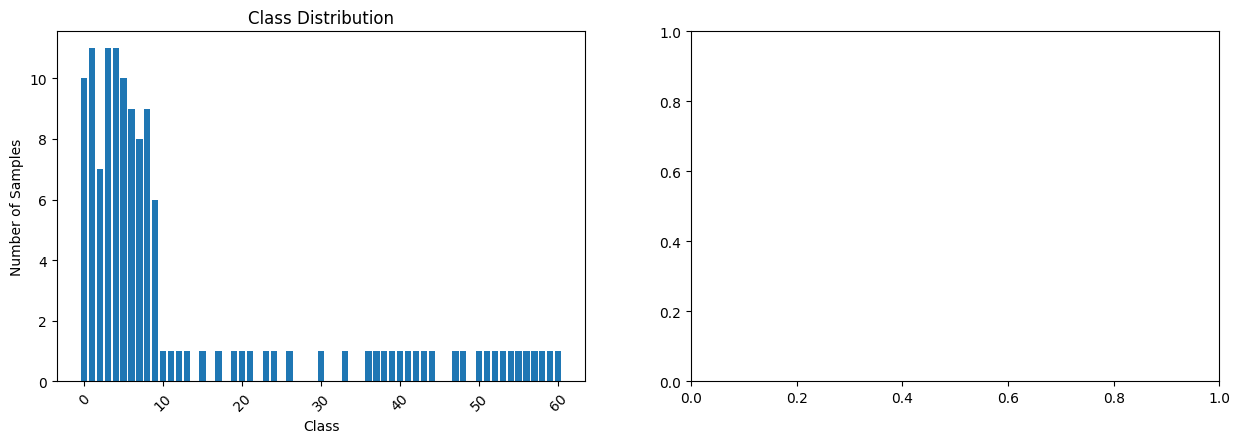

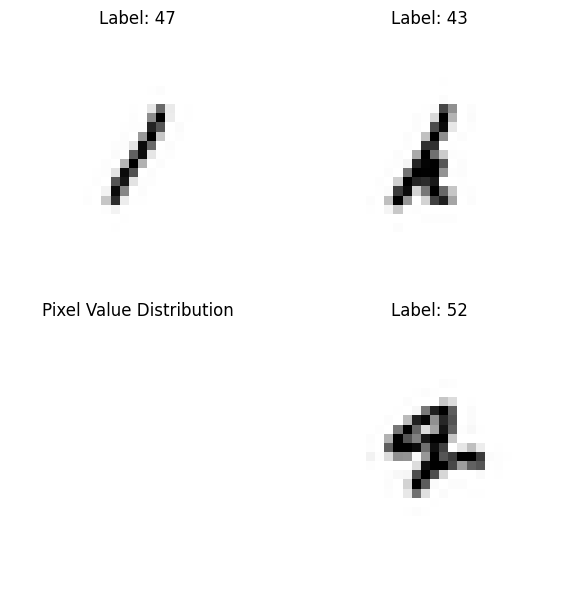


Key Observations:
1. Imbalanced Classes:
   - 46 total classes
   - Most classes have only 1 sample
   - Classes 0-9 have more samples (7-12 each)
   - Classes 37-61 and 10-35 mostly have 1-2 samples

2. Image Statistics:
   - Unusual mean value: 0.961
   - Value range: [0.000, 1.000]
   - Values seem normalized but might need checking

3. Distribution Check:
   - Classes with only 1 sample: 36
   - Percentage of classes with 1 sample: 78.3%


In [156]:
# First part remains the same until visualization
# Step 5: Visualizations
plt.figure(figsize=(15, 10))

# 5.1: Class Distribution Plot
plt.subplot(2, 2, 1)  # Use 2x2 grid, first position
plt.bar(list(label_counts.keys()), list(label_counts.values()))
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45)

# 5.2: Sample Images Grid
plt.subplot(2, 2, 2)  # Second position
grid_size = 2  # Show 2x2 grid of images
fig, axes = plt.subplots(grid_size, grid_size, figsize=(6, 6))
for i in range(grid_size * grid_size):
    row = i // grid_size
    col = i % grid_size
    axes[row, col].imshow(dataset[i][0].squeeze(), cmap='gray')
    axes[row, col].axis('off')
    axes[row, col].set_title(f'Label: {dataset[i][1]}')

# 5.3: Pixel Value Distribution
plt.subplot(2, 2, 3)  # Third position
plt.hist(sample_images.numpy().flatten(), bins=50)
plt.title('Pixel Value Distribution')
plt.xlabel('Pixel Value')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

# Looking at your data statistics:
print("\nKey Observations:")
print("1. Imbalanced Classes:")
print(f"   - {len(label_counts)} total classes")
print(f"   - Most classes have only 1 sample")
print(f"   - Classes 0-9 have more samples (7-12 each)")
print(f"   - Classes 37-61 and 10-35 mostly have 1-2 samples")

print("\n2. Image Statistics:")
print(f"   - Unusual mean value: {sample_images.mean():.3f}")
print(f"   - Value range: [{sample_images.min():.3f}, {sample_images.max():.3f}]")
print("   - Values seem normalized but might need checking")

# Additional checks for dataset quality
print("\n3. Distribution Check:")
low_sample_classes = sum(1 for count in label_counts.values() if count == 1)
print(f"   - Classes with only 1 sample: {low_sample_classes}")
print(f"   - Percentage of classes with 1 sample: {(low_sample_classes/len(label_counts))*100:.1f}%")